# Advanced Network Visualization Patterns (Solution)

Analyze community patterns and layout effects in network charts.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go

sns.set_theme(style="whitegrid")

def resolve_repo_root() -> Path:
    cwd = Path.cwd().resolve()
    for p in [cwd, *cwd.parents]:
        if (p / "data" / "gapminder.csv").exists():
            return p
    raise FileNotFoundError("Cannot locate data/gapminder.csv")

root = resolve_repo_root()
df = pd.read_csv(root / "data" / "gapminder.csv")
d2007 = df[df["year"] == 2007].copy()


## 1) Build toy network + compare layouts

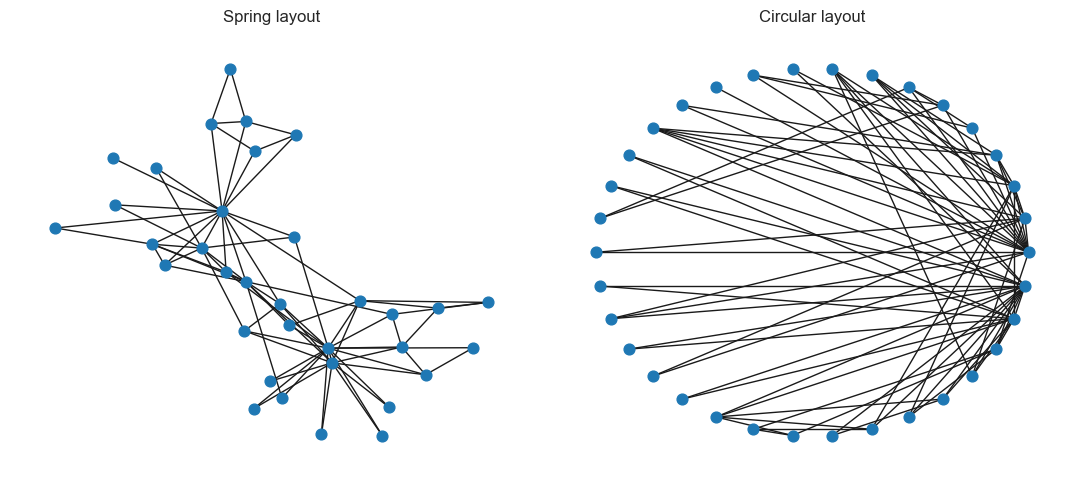

In [2]:
import networkx as nx
G = nx.karate_club_graph()
fig, axes = plt.subplots(1,2, figsize=(11,5))
pos1 = nx.spring_layout(G, seed=42)
pos2 = nx.circular_layout(G)
nx.draw_networkx(G, pos=pos1, node_size=60, with_labels=False, ax=axes[0])
axes[0].set_title('Spring layout')
nx.draw_networkx(G, pos=pos2, node_size=60, with_labels=False, ax=axes[1])
axes[1].set_title('Circular layout')
for ax in axes: ax.axis('off')
plt.tight_layout(); plt.show()

## 2) Degree distribution

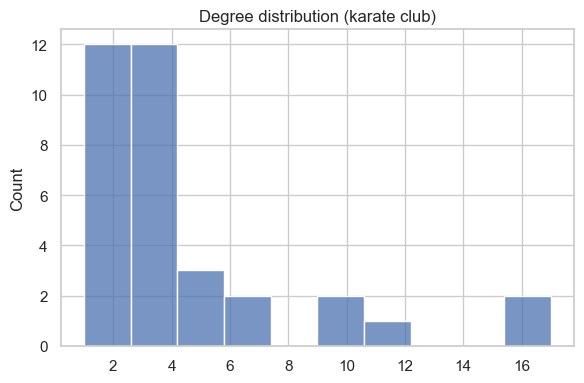

In [3]:
import networkx as nx
deg = [d for _, d in G.degree()]
plt.figure(figsize=(6,4))
sns.histplot(deg, bins=10)
plt.title('Degree distribution (karate club)')
plt.tight_layout(); plt.show()

## Reflection
- Nêu 2 điểm học được về chart selection.
- Chỉ ra 1 rủi ro diễn giải sai với loại chart trong lab này.